In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r'C:\Users\Hello\Downloads\student_digital_life\student_digital_life.csv')
df.head()

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     15000 non-null  int64  
 1   age                            15000 non-null  int64  
 2   gender                         15000 non-null  str    
 3   study_hours_per_day            15000 non-null  float64
 4   smartphone_usage_hours         15000 non-null  float64
 5   social_media_hours             15000 non-null  float64
 6   gaming_hours                   15000 non-null  float64
 7   streaming_hours                15000 non-null  float64
 8   sleep_hours                    15000 non-null  float64
 9   exercise_hours                 15000 non-null  float64
 10  class_attendance_percent       15000 non-null  float64
 11  assignment_completion_percent  15000 non-null  float64
 12  caffeine_intake_cups           15000 non-null  int64  
 1

C:\Users\Hello\AppData\Local\Temp\ipykernel_21868\3182424142.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pass_status', palette=['#2ecc71', '#e74c3c'])


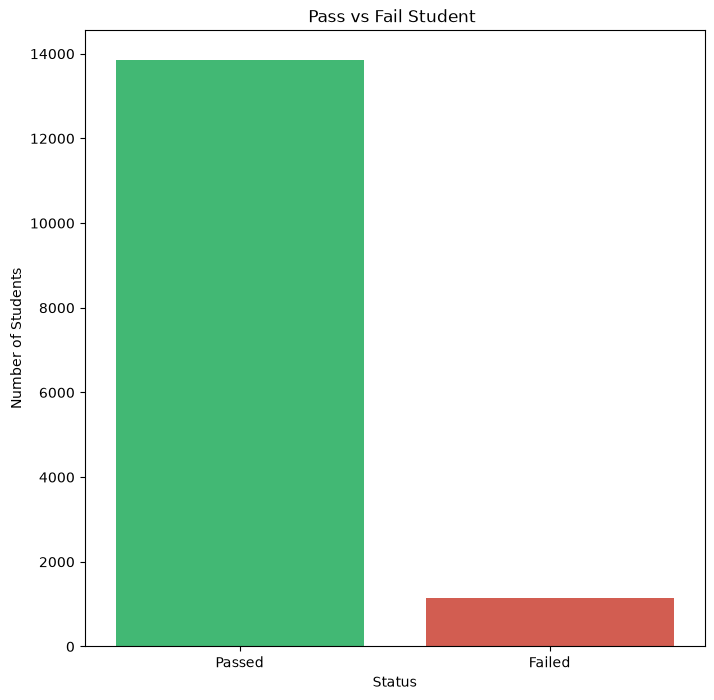

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df['pass_status'] = df['final_exam_score'].apply(lambda x: 'Passed' if x >= 50 else 'Failed')



plt.figure(figsize=(8,8))
sns.countplot(data=df, x='pass_status', palette=['#2ecc71', '#e74c3c'])
plt.title('Pass vs Fail Student ')
plt.xlabel('Status')
plt.ylabel('Number of Students')
plt.show()

parent_education_level
Bachelors     93.05
HighSchool    90.95
Masters       93.73
PhD           93.94
Name: passed, dtype: float64
parent_education_level
Bachelors     6.95
HighSchool    9.05
Masters       6.27
PhD           6.06
Name: failed, dtype: float64


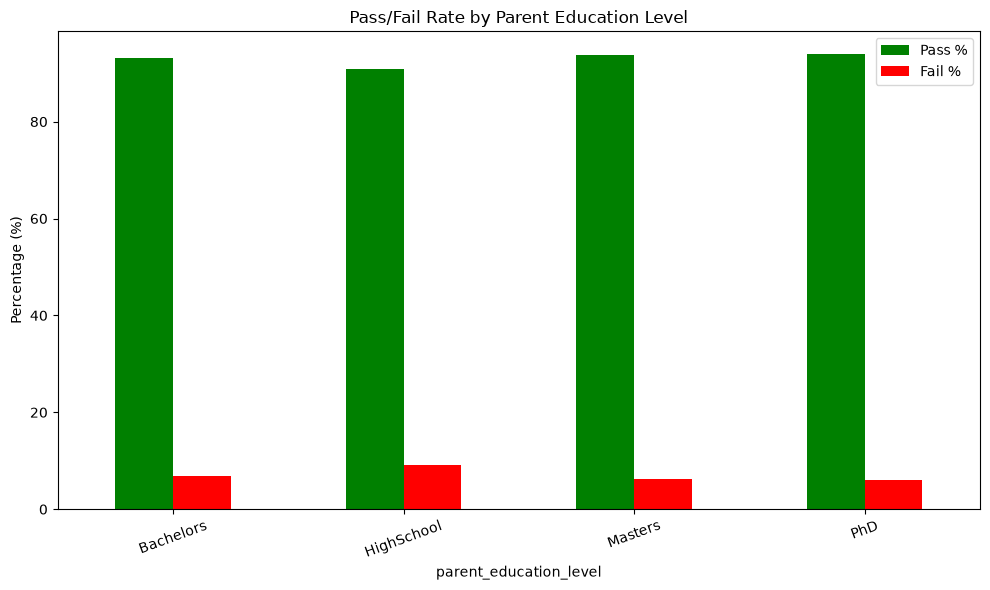

In [9]:
df['passed'] = df['final_exam_score'] >= 50
df['failed'] = df['final_exam_score'] < 50

pass_rate = df.groupby('parent_education_level')['passed'].mean() * 100
fail_rate = df.groupby('parent_education_level')['failed'].mean() * 100

print(pass_rate.round(2))
print(fail_rate.round(2))

summary = pd.DataFrame({'Pass %': pass_rate, 'Fail %': fail_rate})
summary.plot(kind='bar', figsize=(10, 6), color=['green', 'red'])
plt.title('Pass/Fail Rate by Parent Education Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [10]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


df['pass_status'] = df['final_exam_score'].apply(lambda x: 'Passed' if x >= 50 else 'Failed')

school_col = 'parent_education_level' 
schools = df[school_col].unique()

num_cols = [
    'study_hours_per_day', 
    'smartphone_usage_hours', 
    'social_media_hours', 
    'gaming_hours', 
    'streaming_hours', 
    'sleep_hours', 
    'class_attendance_percent', 
    'assignment_completion_percent', 
    'caffeine_intake_cups', 
    'motivation_level'
]


for school in schools:
    school_df = df[df[school_col] == school].copy()

    num_summary = school_df.groupby('pass_status')[num_cols].mean().reset_index()
    
  
    mental_ct = pd.crosstab(school_df['mental_health_status'], school_df['pass_status'], normalize='index') * 100
    mental_ct = mental_ct.reindex(columns=['Failed', 'Passed'], fill_value=0)
    
    internet_ct = pd.crosstab(school_df['internet_quality'], school_df['pass_status'], normalize='index') * 100
    internet_ct = internet_ct.reindex(columns=['Failed', 'Passed'], fill_value=0)

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"colspan": 2}, None],
               [{}, {}]],
        subplot_titles=(
            f'1. Numerical Factors Average in [{school}]',
            f'2. Failure % by Mental Health Status in [{school}]',
            f'3. Failure % by Internet Quality in [{school}]'
        ),
        vertical_spacing=0.15,
        horizontal_spacing=0.08
    )
    

    for status, color in [('Passed', '#2ecc71'), ('Failed', '#e74c3c')]:
        status_row = num_summary[num_summary['pass_status'] == status]
        if not status_row.empty:
            values = status_row[num_cols].values[0]
            fig.add_trace(
                go.Bar(
                    x=num_cols, 
                    y=values, 
                    name=status, 
                    marker_color=color,
                    legendgroup=status,
                    showlegend=True
                ),
                row=1, col=1
            )
            

    for status, color in [('Failed', '#e74c3c'), ('Passed', '#2ecc71')]:
        if status in mental_ct.columns:
            fig.add_trace(
                go.Bar(
                    x=mental_ct.index, 
                    y=mental_ct[status], 
                    name=status, 
                    marker_color=color,
                    legendgroup=status,
                    showlegend=False
                ),
                row=2, col=1
            )
            

    for status, color in [('Failed', '#e74c3c'), ('Passed', '#2ecc71')]:
        if status in internet_ct.columns:
            fig.add_trace(
                go.Bar(
                    x=internet_ct.index, 
                    y=internet_ct[status], 
                    name=status, 
                    marker_color=color,
                    legendgroup=status,
                    showlegend=False
                ),
                row=2, col=2
            )
            
    fig.update_layout(
        title_text=f'<b>Comprehensive Student Analysis Dashboard for [{school}]</b>',
        title_x=0.5,
        height=750,
        barmode='group',
        legend=dict(title="Status", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    # محاور الرسوم البيانية
    fig.update_xaxes(title_text="Factors / Metrics", tickangle=-30, row=1, col=1)
    fig.update_yaxes(title_text="Average Value / %", row=1, col=1)
    
    fig.update_xaxes(title_text="Mental Health Status", row=2, col=1)
    fig.update_yaxes(title_text="Percentage (%)", range=[0, 100], row=2, col=1)
    
    fig.update_xaxes(title_text="Internet Quality", row=2, col=2)
    fig.update_yaxes(title_text="Percentage (%)", range=[0, 100], row=2, col=2)
    
    fig.show()

In [11]:
import plotly.express as px
import plotly.graph_objects as go


passed_df = df[df['pass_status'] == 'Passed']
failed_df = df[df['pass_status'] == 'Failed']

def plot_multi_threshold_interaction(df, x_attr, y_attr, size_attr='smartphone_usage_hours'):
  
    x_danger = failed_df[x_attr].quantile(0.75)   
    x_safe = passed_df[x_attr].quantile(0.20)    
    x_optimal = passed_df[x_attr].quantile(0.70) 
    
    y_danger = failed_df[y_attr].quantile(0.75)
    y_safe = passed_df[y_attr].quantile(0.20)
    y_optimal = passed_df[y_attr].quantile(0.70)
    
    fig = px.scatter(
        df,
        x=x_attr,
        y=y_attr,
        color='pass_status',
        size=size_attr,
        hover_data=['final_exam_score', 'class_attendance_percent', 'smartphone_usage_hours', 'mental_health_status'],
        color_discrete_map={'Passed': '#2ecc71', 'Failed': '#e74c3c'},
        opacity=0.65,
        title=f"<b>Multi-Threshold Analysis: {x_attr} vs {y_attr}</b>"
    )
    
 
    fig.add_vline(x=x_danger, line_dash="dash", line_color="#e74c3c", 
                  annotation_text=f"Danger {x_attr} (< {x_danger:.1f})", annotation_position="top left")
    
    fig.add_vline(x=x_safe, line_dash="dash", line_color="black", 
                  annotation_text=f"Min Safe {x_attr} ({x_safe:.1f})", annotation_position="top right")
    
    fig.add_vline(x=x_optimal, line_dash="dash", line_color="#27ae60", 
                  annotation_text=f"Optimal {x_attr} (> {x_optimal:.1f})", annotation_position="top right")
    

    fig.add_hline(y=y_danger, line_dash="dash", line_color="#e74c3c", 
                  annotation_text=f"Danger {y_attr} (< {y_danger:.1f})", annotation_position="bottom right")
    
    fig.add_hline(y=y_safe, line_dash="dash", line_color="black", 
                  annotation_text=f"Min Safe {y_attr} ({y_safe:.1f})", annotation_position="top right")
    
    fig.add_hline(y=y_optimal, line_dash="dash", line_color="#27ae60", 
                  annotation_text=f"Optimal {y_attr} (> {y_optimal:.1f})", annotation_position="top right")
    
    fig.update_layout(
        xaxis_title=x_attr.replace('_', ' ').title(),
        yaxis_title=y_attr.replace('_', ' ').title(),
        template="plotly_white",
        height=680
    )
    
    fig.show()


plot_multi_threshold_interaction(df, x_attr='study_hours_per_day', y_attr='assignment_completion_percent')